# Cotizaciones AR — ingeniería de datos con arquitectura medallion

Pipeline que ingiere cotizaciones de [DolarAPI](https://dolarapi.com/docs/) (`/v1/dolares` y `/v1/cotizaciones`), las transforma y las guarda en un data lake Parquet local.

| Capa | Rol | Particionado | Duplicados |
| --- | --- | --- | --- |
| **Bronze** | JSON crudo + metadatos de ingestión | `year/month/day/source` | Append-only (bitácora) |
| **Silver** | Hechos limpios y tipados | `year/month/casa` | Upsert por `business_key` + `record_hash` |
| **Gold** | Tablas analíticas listas para consumo | una carpeta por modelo | Se regeneran desde Silver |

## Abrir en Google Colab

Colab abre **un solo archivo**. Este notebook ya trae tablas y gráficos guardados: se ven apenas lo subís, sin ejecutar nada.

1. Entrá a [colab.research.google.com](https://colab.research.google.com).
2. **Archivo → Subir notebook** y elegí `notebooks/cotizaciones_medallion.ipynb`.
3. También sirve subirlo a Google Drive y abrirlo con **Colaboratory**.

Para **volver a correr** el pipeline en Colab hace falta el código (`src/`). En la celda de abajo:

- pegá la URL de GitHub en `REPO_URL`, **o**
- poné `UPLOAD_ZIP = True` y subí un zip del proyecto (incluí `src/`; no hace falta `.venv` ni `data/lake`).

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
import zipfile
from pathlib import Path

# En Colab, para re-ejecutar el pipeline:
REPO_URL = ""          # ej: "https://github.com/usuario/TP.ingdatos.git"
UPLOAD_ZIP = False     # True si vas a subir un zip con src/

IN_COLAB = "google.colab" in sys.modules


def _has_src(path: Path) -> bool:
    return (path / "src" / "pipelines" / "batch.py").exists()


def _discover_root() -> Path | None:
    here = Path.cwd().resolve()
    candidates = [here, here.parent, Path("/content"), Path("/content/TP.ingdatos")]
    for child in here.glob("*"):
        if child.is_dir():
            candidates.append(child)
    for candidate in candidates:
        if _has_src(candidate):
            return candidate
        nested = candidate / "TP.ingdatos"
        if _has_src(nested):
            return nested
    return None


def _extract_uploaded_zip() -> Path:
    from google.colab import files

    print("Subí un .zip del proyecto (incluí src/; no hace falta .venv ni data/lake).")
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No se subió ningún archivo.")

    extract_to = Path("/content/proyecto")
    extract_to.mkdir(parents=True, exist_ok=True)
    zip_name = next(iter(uploaded))
    with zipfile.ZipFile(zip_name) as archive:
        archive.extractall(extract_to)

    root = _discover_root()
    if root is not None:
        return root
    for match in extract_to.rglob("batch.py"):
        if match.parent.name == "pipelines":
            return match.parents[2]
    raise RuntimeError("No encontré src/ en el zip.")


def _bootstrap_colab() -> Path:
    root = _discover_root()
    if root is not None:
        return root

    dest = Path("/content/TP.ingdatos")
    if REPO_URL.strip():
        if not dest.exists():
            subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL.strip(), str(dest)])
        return dest
    if UPLOAD_ZIP:
        return _extract_uploaded_zip()

    raise RuntimeError(
        "En Colab, para re-ejecutar: pegá REPO_URL o poné UPLOAD_ZIP = True. "
        "Si solo querés ver resultados, no hace falta correr las celdas."
    )


ROOT = _discover_root()
if ROOT is None and IN_COLAB:
    ROOT = _bootstrap_colab()
if ROOT is None:
    raise RuntimeError("Ejecutá el notebook desde la raíz del repo o desde notebooks/.")

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pandas>=2.2.0",
            "pyarrow>=16.0.0",
            "requests>=2.32.0",
            "python-dotenv>=1.0.1",
            "matplotlib>=3.8.0",
        ]
    )

import matplotlib.pyplot as plt
import pandas as pd

from src.logging_config import setup_logging
from src.pipelines.batch import run_batch
from src.storage.parquet_store import ParquetLake

setup_logging("INFO")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams.update({"figure.figsize": (10, 4.8), "axes.titlesize": 13, "axes.labelsize": 11})

print("Colab:" if IN_COLAB else "Local:", ROOT)

Proyecto: C:\Users\gonzi\TP.ingdatos


## 1. Ingestión batch

Una corrida consulta ambas fuentes, escribe Bronze, hace merge en Silver (sin repetir hechos) y regenera Gold.

In [2]:
status = run_batch()
pd.Series(status, name="filas").to_frame()

2026-09-05 19:07:34 | INFO     | src.pipelines.batch | Ingestión batch desde https://dolarapi.com


2026-09-05 19:07:34 | INFO     | src.clients.dolar_api | Fuente dolares: 7 registros


2026-09-05 19:07:34 | INFO     | src.clients.dolar_api | Fuente cotizaciones: 5 registros


2026-09-05 19:07:35 | INFO     | src.storage.parquet_store | Bronze: se escribieron 12 filas en data\lake\bronze\quotes


2026-09-05 19:07:35 | INFO     | src.storage.parquet_store | Silver: 12 filas vigentes particionadas por year/month/casa


...

2026-09-05 19:07:35 | INFO     | src.storage.parquet_store | Gold/market_tags: 30 filas


2026-09-05 19:07:35 | INFO     | src.storage.parquet_store | Gold/fx_cross: 4 filas


2026-09-05 19:07:35 | INFO     | src.storage.parquet_store | Gold/variations: 12 filas


2026-09-05 19:07:35 | INFO     | src.pipelines.batch | Batch finalizado | {'bronze': 12, 'silver': 12, 'gold_brecha': 11, 'gold_daily_metrics': 12, 'gold_fx_cross': 4, 'gold_latest': 11, 'gold_market_tags': 30, 'gold_prices_long': 22, 'gold_variations': 12}


,filas
bronze,12
silver,12
gold_brecha,11
gold_daily_metrics,12
gold_fx_cross,4
gold_latest,11
gold_market_tags,30
gold_prices_long,22
gold_variations,12


## 2. Bronze — crudo y auditable

No se limpian campos de negocio: se guarda el JSON original más `ingest_id`, `ingest_ts` y `record_hash`. Cada lote es un archivo nuevo; Bronze nunca se pisa.

In [3]:
lake = ParquetLake()
bronze = lake.read_bronze()
print(f"Filas Bronze: {len(bronze):,} | lotes: {bronze['ingest_id'].nunique()} | fuentes: {sorted(bronze['source'].unique())}")
bronze.head(3)

Filas Bronze: 12 | lotes: 1 | fuentes: ['cotizaciones', 'dolares']


,ingest_id,ingest_ts,endpoint,payload_json,record_hash,year,month,day,source
0,77b808ea-a0e3-4b83-b85d-cb000041ee84,2026-09-05T22:07:34.888900+00:00,/v1/cotizaciones,"{""moneda"": ""USD"", ""casa"": ""oficial"", ""nombre"":...",46c7ad6299ebcee5c2e9d666cfbcaa536c184df232c9a4...,2026,9,5,cotizaciones
1,77b808ea-a0e3-4b83-b85d-cb000041ee84,2026-09-05T22:07:34.888900+00:00,/v1/cotizaciones,"{""moneda"": ""EUR"", ""casa"": ""oficial"", ""nombre"":...",a0f8d0afcf9ece29afaa61dcd053b11f599510ce6e597a...,2026,9,5,cotizaciones
2,77b808ea-a0e3-4b83-b85d-cb000041ee84,2026-09-05T22:07:34.888900+00:00,/v1/cotizaciones,"{""moneda"": ""BRL"", ""casa"": ""oficial"", ""nombre"":...",75765fca0cfab837c2d12eb61956ddf481fc60800a9461...,2026,9,5,cotizaciones


In [4]:
bronze_dir = ROOT / "data" / "lake" / "bronze" / "quotes"
print("Particiones Bronze (Hive):")
for path in sorted(bronze_dir.rglob("*.parquet"))[:8]:
    print(" ", path.relative_to(ROOT))

Particiones Bronze (Hive):
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\0e0f5c43b9e44506a3bb2f6214f06814-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\5fcb0e98ccb9442dbc7ade2b78f78dc2-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\6499bac4e2ba43aa96e490665f90e215-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\e73dbcde154740f799c3e4503a70394c-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=cotizaciones\f7918b47c6d44f9dae1ae0c4cd67fef8-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=dolares\0e0f5c43b9e44506a3bb2f6214f06814-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=dolares\5fcb0e98ccb9442dbc7ade2b78f78dc2-0.parquet
  data\lake\bronze\quotes\year=2026\month=9\day=5\source=dolares\6499bac4e2ba43aa96e490665f90e215-0.parquet


## 3. Silver — más de cuatro transformaciones

Orden de aplicación (todas vectorizadas):

1. Parseo del payload JSON  
2. Normalización de esquema (`fechaActualizacion` → `fecha_actualizacion`)  
3. Imputación de nulos categóricos  
4. Casteo numérico y timestamps UTC  
5. Columnas de partición `year/month/day`  
6. Tags de mercado  
7. `spread`, `mid_price`, `spread_pct`  
8. Reglas de calidad (`quality_ok`, sin borrar filas)  
9. `business_key` + `record_hash`  
10. Deduplicación (se queda la ingestión más reciente)

Clave de negocio: `source|casa|moneda|fecha_actualizacion`.

In [5]:
silver = lake.read_silver()
print(
    f"Filas Silver: {len(silver):,} | claves únicas: {silver['business_key'].nunique()} "
    f"| quality_ok: {int(silver['quality_ok'].sum())}/{len(silver)}"
)
silver[[
    "source", "casa", "moneda", "compra", "venta", "spread", "spread_pct",
    "quality_ok", "fecha_actualizacion_iso", "market_tags",
]].sort_values(["moneda", "casa"]).reset_index(drop=True)

Filas Silver: 12 | claves únicas: 12 | quality_ok: 12/12


,source,casa,moneda,compra,venta,spread,spread_pct,quality_ok,fecha_actualizacion_iso,market_tags
0,cotizaciones,oficial,BRL,296.7322,296.9052,0.1730,0.058302,True,2026-09-04 16:58:00,"regulado,banco,bcra"
1,cotizaciones,oficial,CLP,1.6142,1.6142,0.0000,0.000000,True,2026-09-04 16:58:00,"regulado,banco,bcra"
2,cotizaciones,oficial,EUR,1739.1398,1753.3516,14.2118,0.817174,True,2026-09-04 16:57:00,"regulado,banco,bcra"
3,dolares,blue,USD,1520.0000,1540.0000,20.0000,1.315789,True,2026-09-05 20:56:00,"paralelo,informal"
4,dolares,bolsa,USD,1516.9000,1525.3000,8.4000,0.553761,True,2026-09-05 20:56:00,"financiero,merval,mep"
5,dolares,contadoconliqui,USD,1582.0000,1583.2000,1.2000,0.075853,True,2026-09-05 20:56:00,"financiero,ccl,bursatil"
6,dolares,cripto,USD,1572.2400,1575.1500,2.9100,0.185086,True,2026-09-05 20:56:00,"digital,crypto"
7,dolares,mayorista,USD,1499.0000,1508.0000,9.0000,0.600400,True,2026-09-04 16:48:00,"regulado,interbancario"
8,cotizaciones,oficial,USD,1480.0000,1530.0000,50.0000,3.378378,True,2026-09-04 16:57:00,"regulado,banco,bcra"
9,dolares,oficial,USD,1480.0000,1530.0000,50.0000,3.378378,True,2026-09-04 18:55:00,"regulado,banco,bcra"


In [6]:
print("Bronze crece con cada corrida; Silver no repite el mismo hecho.")
pd.DataFrame(
    {
        "capa": ["bronze", "silver"],
        "filas": [len(bronze), len(silver)],
        "hashes_unicos": [bronze["record_hash"].nunique(), silver["record_hash"].nunique()],
    }
)

Bronze crece con cada corrida; Silver no repite el mismo hecho.


,capa,filas,hashes_unicos
0,bronze,12,12
1,silver,12,12


## 4. Gold — modelos analíticos

Transformaciones extra sobre Silver válido:

- filtro de calidad  
- unpivot compra/venta  
- explode de tags  
- variación vs cotización anterior  
- join as-of contra el dólar oficial  
- agregación diaria y snapshot `latest` (USD desde `dolares`, resto desde `cotizaciones`)

In [7]:
gold_names = ["latest", "brecha", "daily_metrics", "fx_cross", "market_tags", "prices_long", "variations"]
gold = {name: lake.read_gold(name) for name in gold_names}
pd.DataFrame({"tabla": list(gold), "filas": [len(frame) for frame in gold.values()]})

,tabla,filas
0,latest,11
1,brecha,11
2,daily_metrics,12
3,fx_cross,4
4,market_tags,30
5,prices_long,22
6,variations,12


In [8]:
latest = gold["latest"].copy()
latest[["casa", "nombre", "moneda", "compra", "venta", "spread", "spread_pct", "brecha_oficial_pct", "fecha_actualizacion"]]

,casa,nombre,moneda,compra,venta,spread,spread_pct,brecha_oficial_pct,fecha_actualizacion
0,blue,Blue,USD,1520.0000,1540.0000,20.0000,1.315789,0.653595,2026-09-05 20:56:00+00:00
1,bolsa,Bolsa,USD,1516.9000,1525.3000,8.4000,0.553761,-0.30719,2026-09-05 20:56:00+00:00
2,contadoconliqui,Contado Con Liquidación,USD,1582.0000,1583.2000,1.2000,0.075853,3.477124,2026-09-05 20:56:00+00:00
3,cripto,Cripto,USD,1572.2400,1575.1500,2.9100,0.185086,2.95098,2026-09-05 20:56:00+00:00
4,mayorista,Mayorista,USD,1499.0000,1508.0000,9.0000,0.600400,<NA>,2026-09-04 16:48:00+00:00
5,oficial,Real Brasileño,BRL,296.7322,296.9052,0.1730,0.058302,<NA>,2026-09-04 16:58:00+00:00
6,oficial,Peso Chileno,CLP,1.6142,1.6142,0.0000,0.000000,<NA>,2026-09-04 16:58:00+00:00
7,oficial,Euro,EUR,1739.1398,1753.3516,14.2118,0.817174,<NA>,2026-09-04 16:57:00+00:00
8,oficial,Oficial,USD,1480.0000,1530.0000,50.0000,3.378378,0.0,2026-09-04 18:55:00+00:00
9,oficial,Peso Uruguayo,UYU,37.4453,37.4455,0.0002,0.000534,<NA>,2026-09-04 16:58:00+00:00


## 5. Visualizaciones

Lectura directa de Gold: no se vuelve a transformar el crudo.

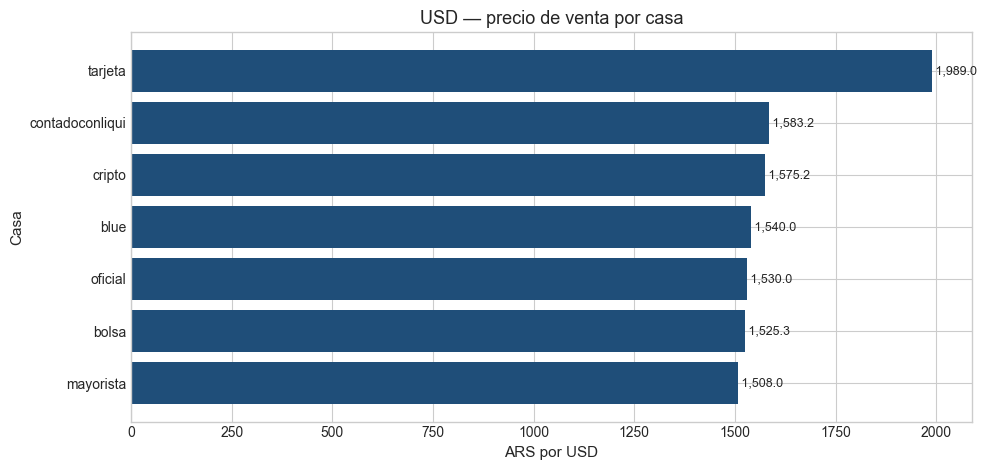

In [9]:
usd = latest.loc[latest["moneda"] == "USD"].sort_values("venta")

fig, ax = plt.subplots()
ax.barh(usd["casa"], usd["venta"], color="#1f4e79")
ax.set_title("USD — precio de venta por casa")
ax.set_xlabel("ARS por USD")
ax.set_ylabel("Casa")
for value, name in zip(usd["venta"], usd["casa"]):
    ax.text(value, name, f" {value:,.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

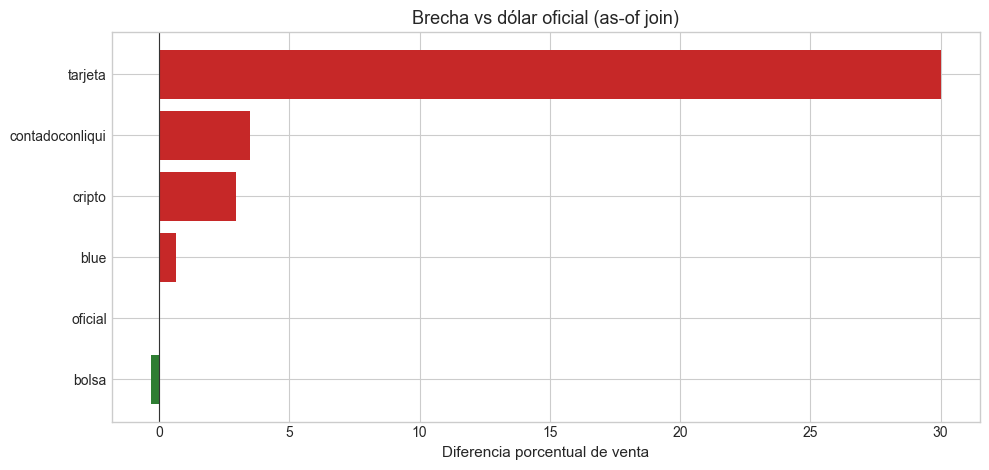

In [10]:
brecha = usd.dropna(subset=["brecha_oficial_pct"]).sort_values("brecha_oficial_pct")
colors = ["#2e7d32" if value <= 0 else "#c62828" for value in brecha["brecha_oficial_pct"]]

fig, ax = plt.subplots()
ax.barh(brecha["casa"], brecha["brecha_oficial_pct"], color=colors)
ax.axvline(0, color="#333", linewidth=0.8)
ax.set_title("Brecha vs dólar oficial (as-of join)")
ax.set_xlabel("Diferencia porcentual de venta")
plt.tight_layout()
plt.show()

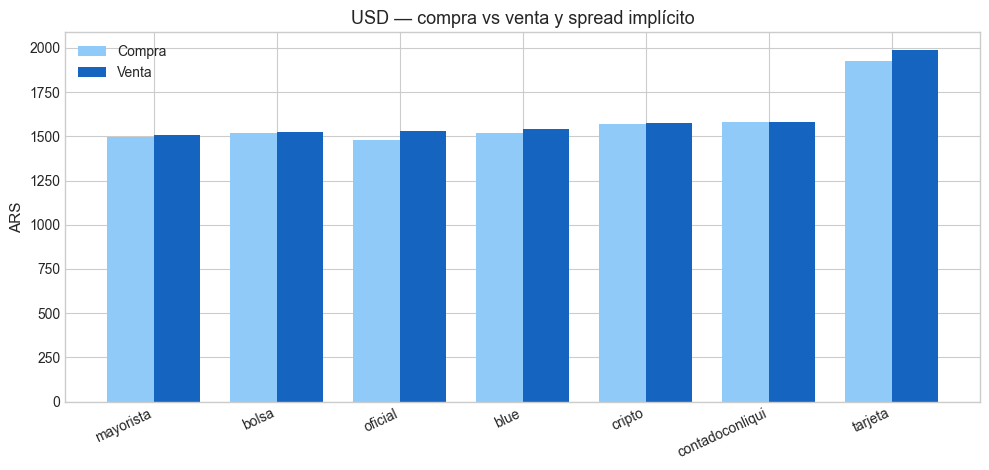

,casa,compra,venta,spread,spread_pct
0,mayorista,1499.00,1508.00,9.00,0.600400
1,bolsa,1516.90,1525.30,8.40,0.553761
2,oficial,1480.00,1530.00,50.00,3.378378
3,blue,1520.00,1540.00,20.00,1.315789
4,cripto,1572.24,1575.15,2.91,0.185086
5,contadoconliqui,1582.00,1583.20,1.20,0.075853
6,tarjeta,1924.00,1989.00,65.00,3.378378


In [11]:
fig, ax = plt.subplots()
idx = range(len(usd))
width = 0.38
ax.bar([i - width / 2 for i in idx], usd["compra"], width=width, label="Compra", color="#90caf9")
ax.bar([i + width / 2 for i in idx], usd["venta"], width=width, label="Venta", color="#1565c0")
ax.set_xticks(list(idx))
ax.set_xticklabels(usd["casa"], rotation=25, ha="right")
ax.set_title("USD — compra vs venta y spread implícito")
ax.set_ylabel("ARS")
ax.legend()
plt.tight_layout()
plt.show()

usd[["casa", "compra", "venta", "spread", "spread_pct"]].reset_index(drop=True)

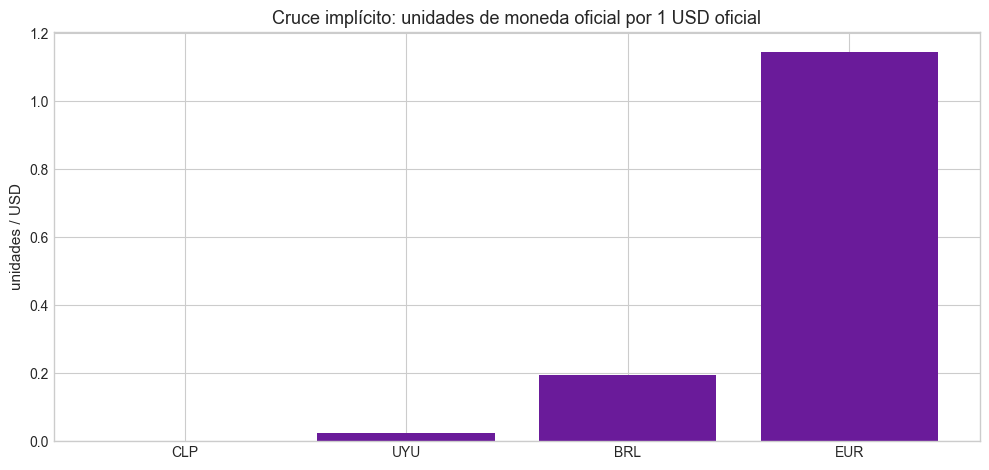

,moneda,nombre,venta_ars,usd_oficial_venta,unidades_por_usd,fecha_actualizacion
1,CLP,Peso Chileno,1.6142,1530.0,0.001055,2026-09-04 16:58:00+00:00
3,UYU,Peso Uruguayo,37.4455,1530.0,0.024474,2026-09-04 16:58:00+00:00
0,BRL,Real Brasileño,296.9052,1530.0,0.194056,2026-09-04 16:58:00+00:00
2,EUR,Euro,1753.3516,1530.0,1.145981,2026-09-04 16:57:00+00:00


In [12]:
fx = gold["fx_cross"].sort_values("unidades_por_usd")
fig, ax = plt.subplots()
ax.bar(fx["moneda"], fx["unidades_por_usd"], color="#6a1b9a")
ax.set_title("Cruce implícito: unidades de moneda oficial por 1 USD oficial")
ax.set_ylabel("unidades / USD")
plt.tight_layout()
plt.show()

fx

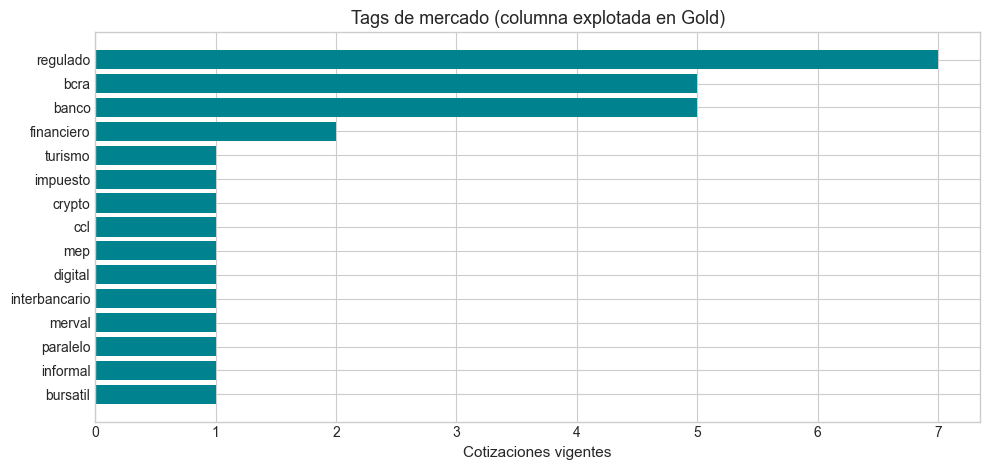

,business_key,source,casa,moneda,fecha_actualizacion,market_tags
0,dolares|blue|USD|2026-09-05 20:56:00+00:00,dolares,blue,USD,2026-09-05 20:56:00+00:00,paralelo
1,dolares|blue|USD|2026-09-05 20:56:00+00:00,dolares,blue,USD,2026-09-05 20:56:00+00:00,informal
2,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,financiero
3,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,merval
4,dolares|bolsa|USD|2026-09-05 20:56:00+00:00,dolares,bolsa,USD,2026-09-05 20:56:00+00:00,mep
5,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,financiero
6,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,ccl
7,dolares|contadoconliqui|USD|2026-09-05 20:56:0...,dolares,contadoconliqui,USD,2026-09-05 20:56:00+00:00,bursatil
8,dolares|cripto|USD|2026-09-05 20:56:00+00:00,dolares,cripto,USD,2026-09-05 20:56:00+00:00,digital
9,dolares|cripto|USD|2026-09-05 20:56:00+00:00,dolares,cripto,USD,2026-09-05 20:56:00+00:00,crypto


In [13]:
tags = gold["market_tags"]
conteo = tags["market_tags"].value_counts().sort_values()

fig, ax = plt.subplots()
ax.barh(conteo.index, conteo.values, color="#00838f")
ax.set_title("Tags de mercado (columna explotada en Gold)")
ax.set_xlabel("Cotizaciones vigentes")
plt.tight_layout()
plt.show()

tags.head(10)

## 6. Tiempo real (micro-lotes)

DolarAPI es REST: no hay websocket. El patrón es un **productor** que consulta cada N segundos y un **consumidor** que escribe Bronze y solo promueve a Silver/Gold si el `record_hash` es nuevo.

```powershell
python -m src.cli stream --interval 20 --cycles 3
```

Si la API no actualizó precios, Bronze crece (auditoría) y Silver se mantiene. Eso es la estrategia de no repetir datos en la capa de negocio.

## 7. Cómo se cubre la consigna

1. **Más de cuatro transformaciones**: parseo, normalización, nulos, tipos, particiones, tags, métricas, calidad, identidad, dedup, unpivot, explode, variación, join as-of y agregación diaria.
2. **Guardado eficiente y sin repetidos**: Parquet + particiones Hive; Bronze append-only; Silver upsert por clave y hash.
3. **Código modular**: `clients`, `transforms`, `storage`, `pipelines` y este notebook solo consume el lake.
4. **Ejecución simple**: `python -m src.cli batch` o *Run All* de este notebook.

Fuente: [dolarapi.com/docs](https://dolarapi.com/docs/).